In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/snehaanbhawal/resume-dataset/Resume/Resume.csv
/kaggle/input/datasets/snehaanbhawal/resume-dataset/data/data/DESIGNER/22506245.pdf
/kaggle/input/datasets/snehaanbhawal/resume-dataset/data/data/DESIGNER/13998435.pdf
/kaggle/input/datasets/snehaanbhawal/resume-dataset/data/data/DESIGNER/67582956.pdf
/kaggle/input/datasets/snehaanbhawal/resume-dataset/data/data/DESIGNER/34349255.pdf
/kaggle/input/datasets/snehaanbhawal/resume-dataset/data/data/DESIGNER/26790545.pdf
/kaggle/input/datasets/snehaanbhawal/resume-dataset/data/data/DESIGNER/12674307.pdf
/kaggle/input/datasets/snehaanbhawal/resume-dataset/data/data/DESIGNER/11807040.pdf
/kaggle/input/datasets/snehaanbhawal/resume-dataset/data/data/DESIGNER/44145704.pdf
/kaggle/input/datasets/snehaanbhawal/resume-dataset/data/data/DESIGNER/27497542.pdf
/kaggle/input/datasets/snehaanbhawal/resume-dataset/data/data/DESIGNER/11155153.pdf
/kaggle/input/datasets/snehaanbhawal/resume-dataset/data/data/DESIGNER/17555081.pdf
/kaggl

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv('/kaggle/input/datasets/snehaanbhawal/resume-dataset/Resume/Resume.csv')
print("Shape:", df.shape)
print("\nCategories:")
print(df['Category'].value_counts().head(10))

Shape: (2484, 4)

Categories:
Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
ENGINEERING               118
ACCOUNTANT                118
FINANCE                   118
FITNESS                   117
AVIATION                  117
SALES                     116
Name: count, dtype: int64


In [3]:
# ML Skills list
ml_skills = ['python', 'machine learning', 'deep learning', 'tensorflow',
             'pytorch', 'sklearn', 'data science', 'neural network',
             'pandas', 'numpy', 'sql', 'statistics', 'nlp']

# Score each resume
def calculate_score(resume_text):
    resume_lower = resume_text.lower()
    matched_skills = [skill for skill in ml_skills if skill in resume_lower]
    return len(matched_skills), matched_skills

df['Resume_str'] = df['Resume_str'].fillna('')
df['Score'], df['Matched_Skills'] = zip(*df['Resume_str'].apply(calculate_score))
df['Match_Percentage'] = (df['Score'] / len(ml_skills) * 100).round(2)

# Top 10 candidates
top10 = df.nlargest(10, 'Score')[['Category', 'Score', 'Match_Percentage', 'Matched_Skills']]
print("Top 10 Candidates:")
print(top10)

Top 10 Candidates:
                    Category  Score  Match_Percentage  \
1339              AUTOMOBILE      6             46.15   
1348              AUTOMOBILE      5             38.46   
1717             ENGINEERING      5             38.46   
1762             ENGINEERING      5             38.46   
926              AGRICULTURE      4             30.77   
929              AGRICULTURE      4             30.77   
1218              CONSULTANT      4             30.77   
2153                 BANKING      4             30.77   
291   INFORMATION-TECHNOLOGY      3             23.08   
315   INFORMATION-TECHNOLOGY      3             23.08   

                                         Matched_Skills  
1339  [python, data science, pandas, numpy, sql, sta...  
1348  [python, machine learning, neural network, sql...  
1717  [python, machine learning, tensorflow, pandas,...  
1762  [python, machine learning, pandas, sql, statis...  
926                   [python, tensorflow, pandas, sql]  
929  

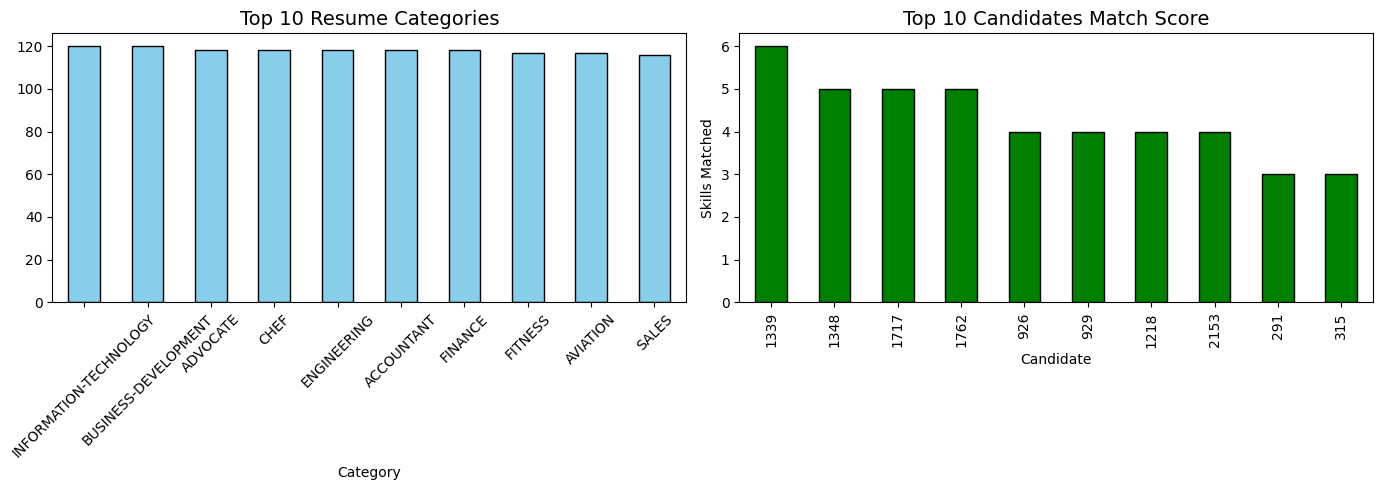


Top Candidate Category: AUTOMOBILE
Matched Skills: ['python', 'data science', 'pandas', 'numpy', 'sql', 'statistics']
Missing Skills: ['machine learning', 'deep learning', 'tensorflow', 'pytorch', 'sklearn', 'neural network', 'nlp']
Match Score: 46.15%

✅ Task 3 Complete!


In [4]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Category distribution
df['Category'].value_counts().head(10).plot(kind='bar', ax=axes[0],
                                             color='skyblue', edgecolor='black')
axes[0].set_title('Top 10 Resume Categories', fontsize=14)
axes[0].tick_params(axis='x', rotation=45)

# Top candidates score
top10['Score'].plot(kind='bar', ax=axes[1],
                    color='green', edgecolor='black')
axes[1].set_title('Top 10 Candidates Match Score', fontsize=14)
axes[1].set_xlabel('Candidate')
axes[1].set_ylabel('Skills Matched')

plt.tight_layout()
plt.show()

# Skill gap analysis
top_resume = df.nlargest(1, 'Score').iloc[0]
matched = top_resume['Matched_Skills']
missing = [skill for skill in ml_skills if skill not in matched]
print(f"\nTop Candidate Category: {top_resume['Category']}")
print(f"Matched Skills: {matched}")
print(f"Missing Skills: {missing}")
print(f"Match Score: {top_resume['Match_Percentage']}%")
print("\n✅ Task 3 Complete!")